       show_id     type                                        title  \
0     81145628    Movie      Norm of the North: King Sized Adventure   
1     80117401    Movie                   Jandino: Whatever it Takes   
2     70234439  TV Show                           Transformers Prime   
3     80058654  TV Show             Transformers: Robots in Disguise   
4     80125979    Movie                                 #realityhigh   
...        ...      ...                                          ...   
6229  80000063  TV Show                                 Red vs. Blue   
6230  70286564  TV Show                                        Maron   
6231  80116008    Movie       Little Baby Bum: Nursery Rhyme Friends   
6232  70281022  TV Show  A Young Doctor's Notebook and Other Stories   
6233  70153404  TV Show                                      Friends   

                      director  \
0     Richard Finn, Tim Maltby   
1                          NaN   
2                          NaN   

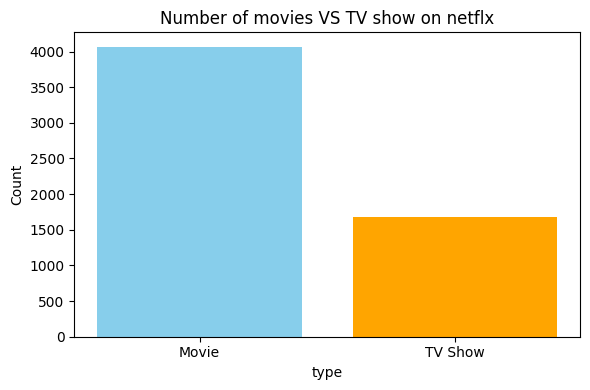

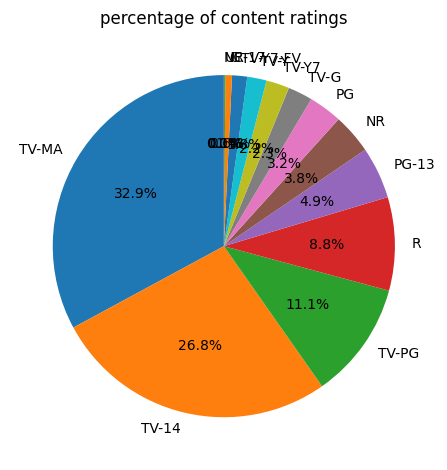

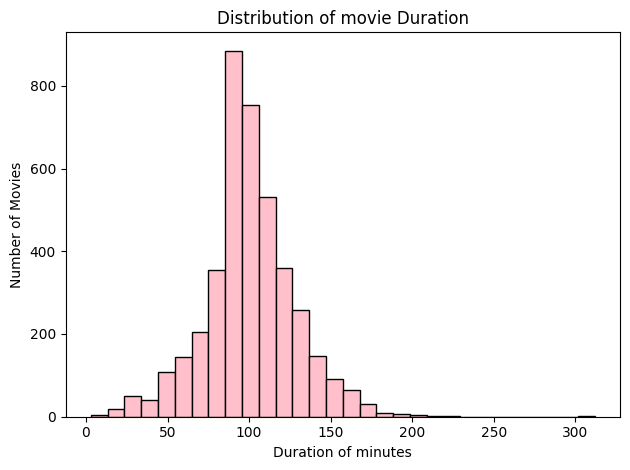

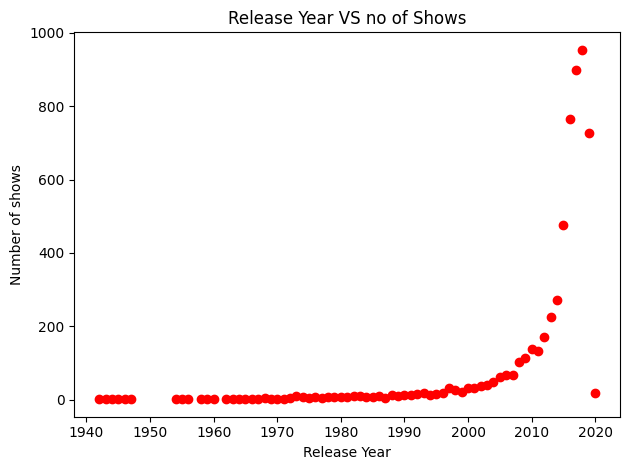

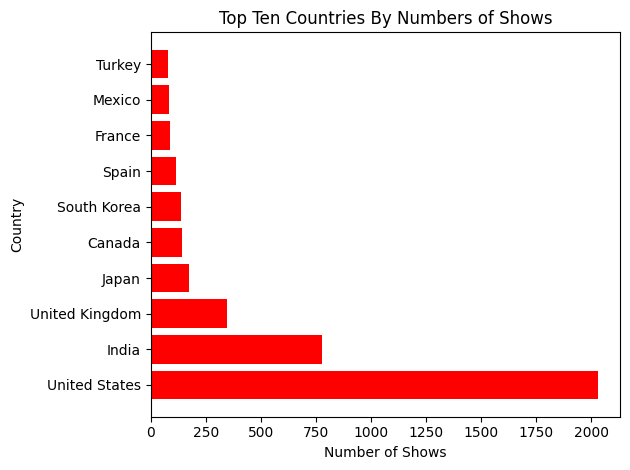

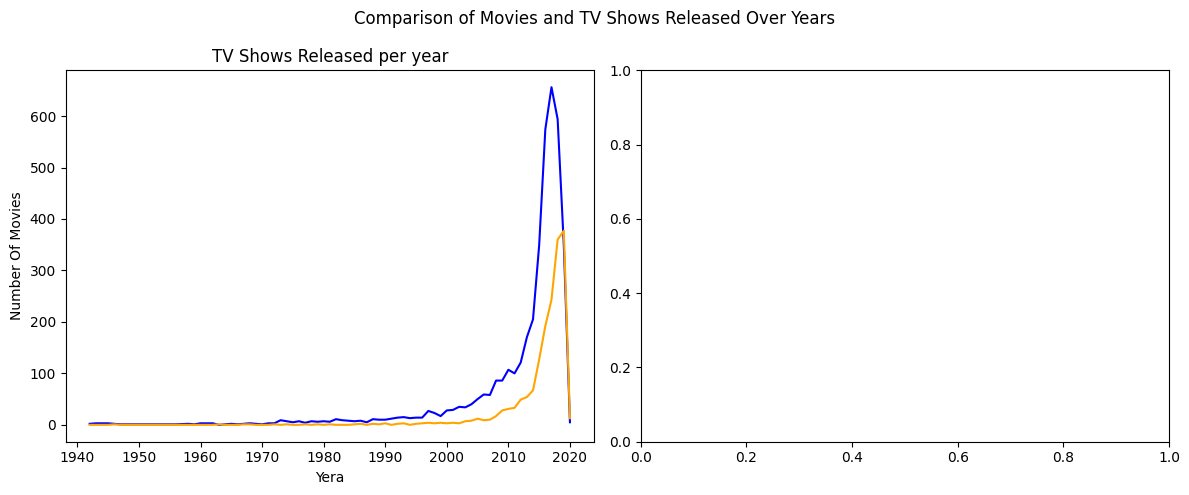

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv('C:/Users/User/Desktop/data_analysis_project/matplotlib sgr/netflix_titles.csv')
print(data)

# clean data
data = data.dropna(subset=['type','release_year','rating','country','duration'])

# bar chart  movies vs tv.show
type_counts = data['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values, color=['skyblue', 'orange'])
plt.title('Number of movies VS TV show on netflx')
plt.xlabel('type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movies_VS_tvshow.png')
plt.show()

rating_count = data['rating'].value_counts()
plt.Figure(figsize=(8,6))
plt.pie(rating_count, labels=rating_count.index, autopct='%1.1f%%', startangle=90)
plt.title('percentage of content ratings')
plt.tight_layout()
plt.savefig('content_rating_pie.png')
plt.show()

movie_df = data[data['type'] == 'Movie'].copy()
movie_df['duration_int'] = movie_df['duration'].str.replace('min','').astype(int)

plt.Figure(figsize=[8,6])
plt.hist(movie_df['duration_int'], bins=30, color='pink', edgecolor='black')
plt.title('Distribution of movie Duration')
plt.xlabel('Duration of minutes')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('movie_duration_hist.png')
plt.show()

release_count = data['release_year'].value_counts().sort_index()
plt.Figure(figsize=(10,6))
plt.scatter(release_count.index, release_count.values, color='red')
plt.title('Release Year VS no of Shows')
plt.xlabel('Release Year')
plt.ylabel('Number of shows')
plt.tight_layout()
plt.savefig('release_year_Scatter.png')
plt.show()

country_counts = data['country'].value_counts().head(10)
plt.Figure(figsize=(8,6))
plt.barh(country_counts.index, country_counts.values, color='red')
plt.title('Top Ten Countries By Numbers of Shows')
plt.xlabel('Number of Shows')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('top10_countries.png')
plt.show()

content_by_year = data.groupby(['release_year', 'type']).size().unstack().fillna(0)

fig, ax = plt.subplots(1,2, figsize=(12,5))
# 1st subplot movies
ax[0].plot(content_by_year.index, content_by_year['Movie'],color='blue')
ax[0].set_title('Movies Released per year')
ax[0].set_xlabel('Yera')
ax[0].set_ylabel('Number Of Movies')


ax[0].plot(content_by_year.index, content_by_year['TV Show'],color='orange')
ax[0].set_title('TV Shows Released per year')
ax[0].set_xlabel('Yera')
ax[0].set_ylabel('Number Of Movies')

fig.suptitle('Comparison of Movies and TV Shows Released Over Years')
plt.tight_layout()
plt.savefig('Movies_tv_shows_comparison.png')
plt.show()